<a href="https://colab.research.google.com/github/ayushi777lodhi-stack/Vision-MultiModal-Learning/blob/main/vae.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
BATCH_SIZE=128
data_transform=transforms.Compose([transforms.ToTensor()])

train_dataset=datasets.MNIST(root="./data", train=True, transform =data_transform, download=True)
train_loader=DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 493kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.3MB/s]


In [4]:
latent_dim=64

class VAE(nn.Module):
  def __init__(self, input_dim=784, hidden_dim=256, latent_dim=latent_dim):
    super().__init__()

    self.fc1=nn.Linear(input_dim,hidden_dim)
    self.fc_mu=nn.Linear(hidden_dim,latent_dim)
    self.fc_logvar=nn.Linear(hidden_dim,latent_dim)

    self.fc2=nn.Linear(latent_dim,hidden_dim)
    self.fc3=nn.Linear(hidden_dim,input_dim)

    self.relu=nn.ReLU()
    self.sigmoid=nn.Sigmoid()

  def encode(self,x):
    h=self.relu(self.fc1(x))
    mu=self.fc_mu(h)
    logvar=self.fc_logvar(h)
    return mu,logvar


  def reparamaterize(self, mu, logvar):
    std=torch.exp(0.5*logvar)
    eps=torch.randn_like(std)
    z=mu+eps*std
    return z


  def decode(self,z):
    h=self.relu(self.fc2(z))
    out=self.sigmoid(self.fc3(h))
    return out


  def forward(self,x):
    mu,logvar=self.encode(x)
    z=self.reparamaterize(mu,logvar)
    x_reconstructed=self.decode(z)
    return x_reconstructed, mu, logvar

In [5]:
def vae_loss(recon_x,x,mu,logvar):
  recon_loss=nn.functional.binary_cross_entropy(recon_x,x,reduction="sum")
  kl_loss=0.5*torch.sum(mu**2+logvar.exp()-logvar-1)
  return recon_loss+kl_loss

In [6]:
model = VAE().to(device)
optimizer=optim.Adam(model.parameters(),lr=1e-3)


In [7]:
epochs=10
model.train()
for epoch in range(epochs):
  total_loss=0

  for x,_ in (train_loader):
    x=x.view(-1,784).to(device)
    optimizer.zero_grad()
    x_recon,mu,logvar=model(x)
    loss=vae_loss(x_recon, x, mu, logvar)
    loss.backward()
    optimizer.step()

    total_loss+=loss.item()

  avg_loss=total_loss/len(train_loader.dataset)

  print(f"epoch{epoch+1}/{epochs}, loss:{avg_loss:.4f}")

epoch1/10, loss:179.7264
epoch2/10, loss:133.9657
epoch3/10, loss:122.4061
epoch4/10, loss:116.7294
epoch5/10, loss:113.6192
epoch6/10, loss:111.7527
epoch7/10, loss:110.4476
epoch8/10, loss:109.5172
epoch9/10, loss:108.7935
epoch10/10, loss:108.1629


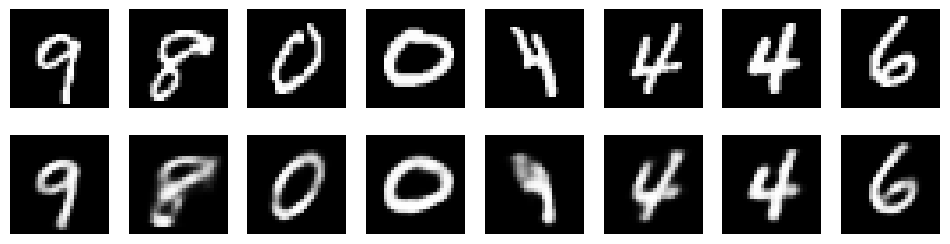

In [8]:
model.eval()

with torch.no_grad():
  x,_=next(iter(train_loader))
  x=x.view(-1,784).to(device)

  x_recon,_,_=model(x)
  x=x.cpu()
  x_recon=x_recon.cpu()

  n=8
  plt.figure(figsize=(12,3))

  for i in range(n):
    plt.subplot(2,n,i+1)
    plt.imshow(x[i].view(28,28).cpu(), cmap="gray")
    plt.axis("off")

    plt.subplot(2,n,n+i+1)
    plt.imshow(x_recon[i].view(28,28).cpu(), cmap="gray")
    plt.axis("off")


  plt.show()


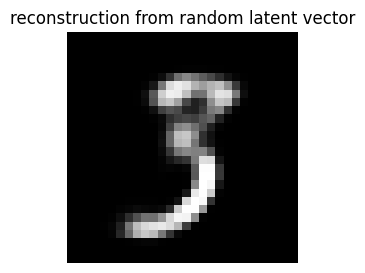

In [9]:
model.eval()

with torch.no_grad():

  z_random=torch.randn(1,latent_dim).to(device)

  x_generated=model.decode(z_random)
  x_generated=x_generated.cpu().view(28,28)


plt.figure(figsize=(3,3))
plt.imshow(x_generated, cmap="gray")
plt.axis("off")
plt.title("reconstruction from random latent vector")
plt.show()